<a href="https://colab.research.google.com/github/nayanajiju/INTERNSHIP/blob/main/preprocessing%20test_Day%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    int64  
 1   Age                 90 non-null     float64
 2   Gender              100 non-null    object 
 3   Department          90 non-null     object 
 4   Education           90 non-null     object 
 5   Experience_Years    100 non-null    int64  
 6   Monthly_Salary      90 non-null     float64
 7   Performance_Rating  100 non-null    int64  
 8   City                90 non-null     object 
 9   Attrition           100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


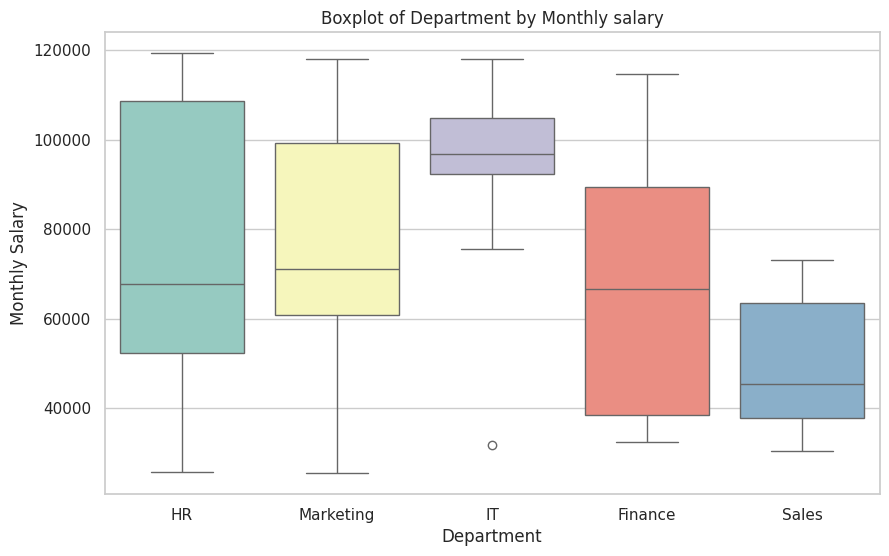

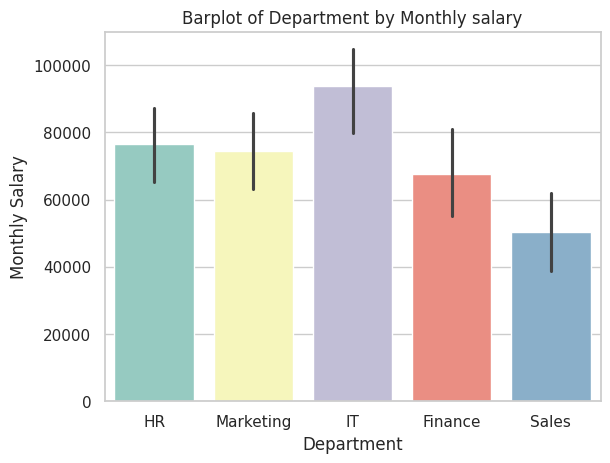

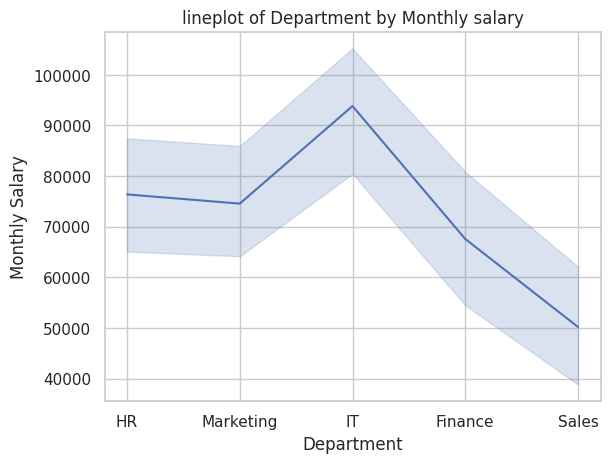

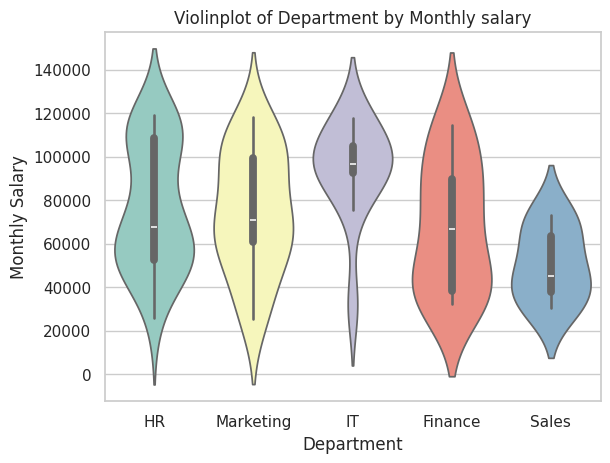

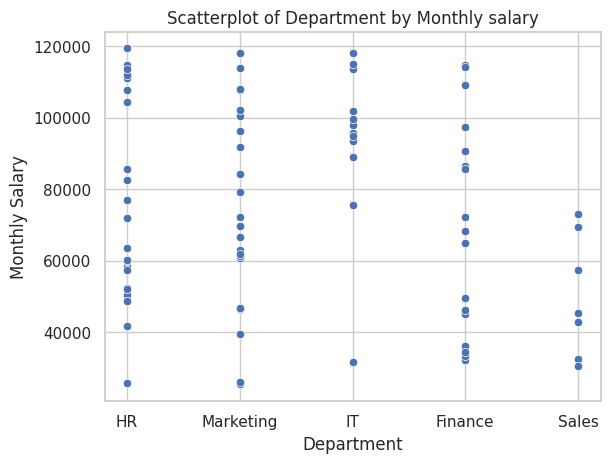

   Gender  Gender_Label Department  Department_HR  Department_Marketing  \
0    Male             1         HR           True                 False   
1  Female             0  Marketing          False                  True   
2  Female             0         HR           True                 False   
3  Female             0         HR           True                 False   
4    Male             1         IT          False                 False   

   Department_IT  Department_Finance  Department_Sales  Performance_Rating  \
0          False               False             False                   5   
1          False               False             False                   2   
2          False               False             False                   1   
3          False               False             False                   2   
4           True               False             False                   3   

  Performance_Rating_Category  
0                   Excellent  
1               

,Age,Age_MinMax,Age_Standard,Monthly_Salary,Monthly_Salary_MinMax,Monthly_Salary_Standard
0,59.0,1.000000,1.811984,52350.0,0.286925,-0.802101
1,49.0,0.736842,0.889855,118008.0,0.986270,1.557801
2,35.0,0.368421,-0.401126,119297.0,1.000000,1.604131
3,28.0,0.184211,-1.046617,50351.0,0.265633,-0.873950
4,41.0,0.526316,0.152151,113668.0,0.940044,1.401811
...,...,...,...,...,...,...
95,54.0,0.868421,1.350919,48625.0,0.247249,-0.935986
96,53.0,0.842105,1.258706,107873.0,0.878319,1.193525
97,43.0,0.578947,0.336577,97592.0,0.768813,0.824002
98,44.0,0.605263,0.428790,102052.0,0.816318,0.984305


In [ ]:
import pandas as pd

df = pd.read_csv("/content/preprocessing_practice_dataset.csv")

df

df.head()

df.tail()

df.tail(5)

df.info()

df.shape

df.dtypes

df.describe()

df.isnull()

df.isnull().sum()

df['Age_mean_imputed'] = df['Age'].fillna(df['Age'].mean())

df['Age_median_imputed'] = df['Age'].fillna(df['Age'].median())

df['Monthly_Salary_mean_imputed'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())
df['Monthly_salary_median_imputed'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].median())

df['Department_mode_imputed'] = df['Department'].fillna(df['Department'].mode()[0])

df['Education_mode_imputed'] = df['Education'].fillna(df['Education'].mode()[0])
df['City_mode_imputed'] = df['City'].fillna(df['City'].mode()[0])

df[['Age','Age_mean_imputed','Age_median_imputed']]

df[['Monthly_Salary','Monthly_Salary_mean_imputed','Monthly_salary_median_imputed']]

df[['Department','Department_mode_imputed','Education','Education_mode_imputed','City','City_mode_imputed']]

import seaborn as sns

import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='Department', y='Monthly_Salary', palette='Set3', hue='Department', legend=False)
plt.title('Boxplot of Department by Monthly salary')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Salary', fontsize=12)
plt.show()

sns.barplot(data=df, x='Department', y='Monthly_Salary', palette='Set3', hue='Department', legend=False)
plt.title('Barplot of Department by Monthly salary')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Salary', fontsize=12)
plt.show()

sns.lineplot(data=df, x='Department', y='Monthly_Salary')
plt.title('lineplot of Department by Monthly salary')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Salary', fontsize=12)
plt.show()

sns.violinplot(data=df, x='Department', y='Monthly_Salary', palette='Set3', hue='Department', legend=False)
plt.title('Violinplot of Department by Monthly salary')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Salary', fontsize=12)
plt.show()

sns.scatterplot(data=df, x='Department', y='Monthly_Salary')
plt.title('Scatterplot of Department by Monthly salary')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Monthly Salary', fontsize=12)
plt.show()

from sklearn.preprocessing import LabelEncoder

encoded_data = df.copy()

label_encoder = LabelEncoder()

encoded_data['Gender_Label'] = label_encoder.fit_transform(encoded_data['Gender'])

one_hot_encoded = pd.get_dummies(encoded_data['Department'], prefix='Department')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

Performance_Rating_mapping = {1:'Poor', 2:'Fair', 3:'Good', 4:'Excellent', 5:'Excellent'}
encoded_data['Performance_Rating_Category'] = encoded_data['Performance_Rating'].map(Performance_Rating_mapping)

print(encoded_data[['Gender','Gender_Label','Department','Department_HR','Department_Marketing','Department_IT','Department_Finance','Department_Sales','Performance_Rating','Performance_Rating_Category']].head())

from sklearn.preprocessing import MinMaxScaler, StandardScaler

numerical_columns = ['Age', 'Monthly_Salary']

prepro_data = df.copy()

prepro_data.dropna(subset=numerical_columns, inplace=True)

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

prepro_data['Age_MinMax'] = minmax_scaler.fit_transform(prepro_data[['Age']])
prepro_data['Monthly_Salary_MinMax'] = minmax_scaler.fit_transform(prepro_data[['Monthly_Salary']])

prepro_data['Age_Standard'] = standard_scaler.fit_transform(prepro_data[['Age']])
prepro_data['Monthly_Salary_Standard'] = standard_scaler.fit_transform(prepro_data[['Monthly_Salary']])

prepro_data[['Age','Age_MinMax','Age_Standard','Monthly_Salary','Monthly_Salary_MinMax','Monthly_Salary_Standard']]